# SC 612 104 Essential Data Science
## SQL พื้นฐาน: ER Diagram, สร้างฐานข้อมูล SQLite, และ SELECT พื้นฐาน

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### เนื้อหาใน Notebook นี้
1. ทำไมต้องเรียน SQL และฐานข้อมูลเชิงสัมพันธ์ (Relational Database)
2. ER Diagram — ออกแบบฐานข้อมูลร้านค้าออนไลน์จำลอง
3. สร้างฐานข้อมูลด้วย `CREATE TABLE`
4. Data Types ใน SQLite
5. Constraints (PRIMARY KEY, FOREIGN KEY, NOT NULL, UNIQUE, CHECK)
6. `INSERT INTO` — เพิ่มข้อมูลเข้าตาราง
7. `SELECT`, `WHERE`, `ORDER BY`, `LIMIT`
8. `GROUP BY`, `HAVING`, และ Aggregate Functions

**แบบฝึกหัดท้ายเรื่อง** (ไม่มีเฉลย)

> 🛠️ **เครื่องมือที่ใช้:** ไฟล์นี้ใช้ `sqlite3` ซึ่งเป็นส่วนหนึ่งของ Python มาตรฐาน (ไม่ต้องติดตั้งเพิ่ม) — SQLite เป็นระบบฐานข้อมูลขนาดเล็กที่เก็บทั้งฐานข้อมูลไว้ในไฟล์เดียว (`.db`) เหมาะสำหรับการเรียนรู้และโปรเจกต์ขนาดเล็ก-กลาง


---
## 1. ทำไมต้องเรียน SQL?

จนถึงตอนนี้ข้อมูลที่ใช้มาจากไฟล์ CSV โหลดด้วย `pd.read_csv()` — แต่ในงานจริง ข้อมูลขององค์กรส่วนใหญ่ถูกเก็บใน **ฐานข้อมูล (Database)** ไม่ใช่ไฟล์ CSV เพราะ:
- รองรับข้อมูลขนาดใหญ่กว่าไฟล์เดียวได้มาก
- หลายคน/หลายโปรแกรมเข้าถึงพร้อมกันได้โดยข้อมูลไม่เสียหาย
- มีกลไกป้องกันข้อมูลผิดพลาด (constraints) ตั้งแต่ตอนบันทึกข้อมูล
- ดึงข้อมูลเฉพาะส่วนที่ต้องการได้อย่างมีประสิทธิภาพ แม้ข้อมูลทั้งหมดมีขนาดใหญ่มาก

**SQL (Structured Query Language)** คือภาษามาตรฐานที่ใช้สื่อสารกับฐานข้อมูลเชิงสัมพันธ์ (Relational Database) — ใช้ได้กับฐานข้อมูลแทบทุกระบบ (SQLite, MySQL, PostgreSQL, SQL Server) ด้วยไวยากรณ์ที่คล้ายกันมาก เป็นทักษะพื้นฐานที่สำคัญที่สุดอันหนึ่งของงาน Data Analyst/Data Scientist

**ฐานข้อมูลเชิงสัมพันธ์ (Relational Database)** เก็บข้อมูลเป็น**ตาราง**หลายตารางที่**เชื่อมโยงกัน** ผ่านคีย์ — ต่างจาก DataFrame เดี่ยวๆที่เคยใช้ ฐานข้อมูลจะแยกข้อมูลออกเป็นหลายตารางเพื่อลดความซ้ำซ้อน (เรียกว่า Normalization) แล้วใช้ SQL ดึงข้อมูลที่ต้องการมารวมกันเมื่อต้องใช้งาน


---
## 2. ER Diagram — ออกแบบฐานข้อมูลร้านค้าออนไลน์จำลอง

**ER Diagram (Entity-Relationship Diagram)** คือแผนภาพที่ใช้ออกแบบโครงสร้างฐานข้อมูลก่อนสร้างจริง — แสดง **Entity** (ตาราง), **Attribute** (คอลัมน์), และ **Relationship** (ความสัมพันธ์ระหว่างตาราง)

เปรียบเทียบกับที่เรียนมา: ER Diagram สำหรับฐานข้อมูล มีบทบาทคล้าย Flowchart สำหรับ logic ของโปรแกรม — ทั้งสองคือ "เครื่องมือออกแบบก่อนลงมือสร้างจริง"

ในคาบนี้จะออกแบบฐานข้อมูลสำหรับ **ร้านค้าออนไลน์จำลอง** ที่มี 4 ตาราง: ลูกค้า (customers), สินค้า (products), คำสั่งซื้อ (orders), และรายการสินค้าในคำสั่งซื้อ (order_items)


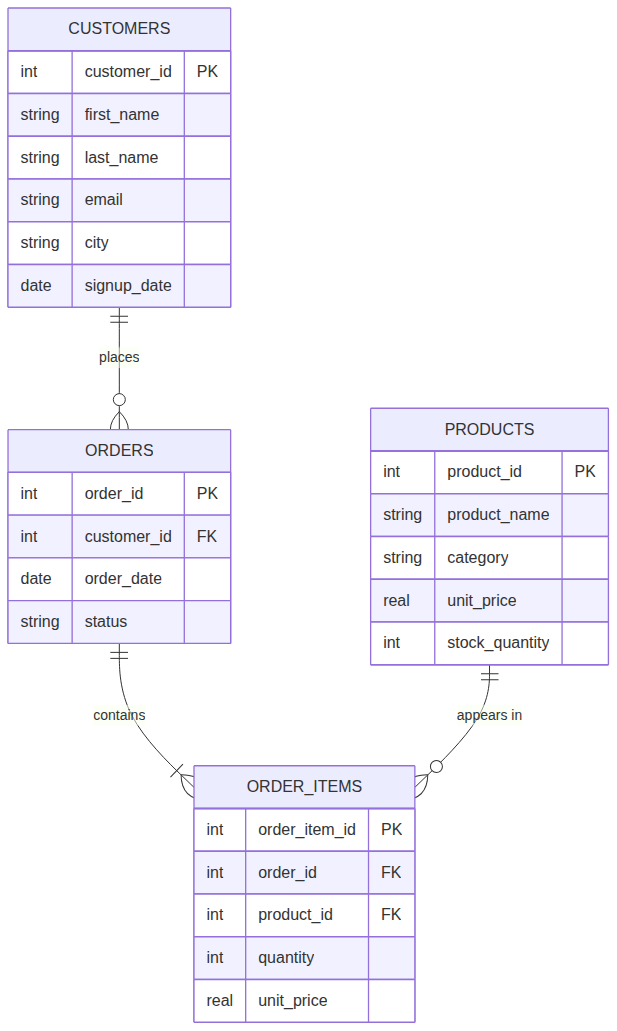


### 2.1 อ่าน ER Diagram อย่างไร

**สัญลักษณ์ความสัมพันธ์ (Crow's Foot Notation):**

| สัญลักษณ์ | ความหมาย |
|---|---|
| `\|\|` | ต้องมี 1 (exactly one) |
| `o{` | มีได้ 0 หรือมากกว่า (zero or many) |
| `\|{` | ต้องมีอย่างน้อย 1 และมากกว่าได้ (one or many) |

**ความสัมพันธ์ในฐานข้อมูลนี้:**
- **CUSTOMERS ||--o{ ORDERS** → ลูกค้า 1 คน สั่งซื้อได้ 0 ครั้งหรือมากกว่า (1-to-many) — ลูกค้าบางคนอาจยังไม่เคยสั่งซื้อเลย
- **ORDERS ||--|{ ORDER_ITEMS** → คำสั่งซื้อ 1 รายการ มีสินค้าอย่างน้อย 1 ชิ้นขึ้นไป (1-to-many)
- **PRODUCTS ||--o{ ORDER_ITEMS** → สินค้า 1 ชนิด ถูกสั่งซื้อได้ 0 ครั้งหรือมากกว่า (1-to-many) — สินค้าบางตัวอาจยังไม่เคยถูกสั่งซื้อเลย

**ทำไมต้องมีตาราง `order_items` แยกจาก `orders`?**

เพราะ 1 คำสั่งซื้อ (order) มีสินค้าได้หลายชิ้น และสินค้า 1 ชนิดก็ถูกสั่งซื้อในหลายคำสั่งซื้อได้ — นี่คือความสัมพันธ์แบบ **many-to-many** ระหว่าง `orders` กับ `products` ซึ่งฐานข้อมูลเชิงสัมพันธ์จะใช้ตารางตัวกลาง (เรียกว่า **junction table** หรือ **bridge table**) อย่าง `order_items` มาเชื่อมทั้งสองตารางเข้าด้วยกัน

### 2.2 Primary Key (PK) และ Foreign Key (FK)

| คำย่อ | ชื่อเต็ม | ความหมาย |
|---|---|---|
| **PK** | Primary Key | คอลัมน์ที่ใช้ระบุแต่ละแถวอย่างไม่ซ้ำกัน (เหมือน index ที่ไม่ซ้ำ) |
| **FK** | Foreign Key | คอลัมน์ที่อ้างอิงไปยัง Primary Key ของอีกตาราง (ใช้เชื่อมตาราง) |

เช่น `orders.customer_id` เป็น FK ที่อ้างอิงไปยัง `customers.customer_id` — บอกว่าคำสั่งซื้อนี้เป็นของลูกค้าคนไหน


---
## 3. สร้างฐานข้อมูลด้วย `CREATE TABLE`

มาเริ่มสร้างฐานข้อมูลจริงตาม ER Diagram ที่ออกแบบไว้ — ใช้ `sqlite3` ของ Python เชื่อมต่อกับไฟล์ฐานข้อมูล


In [1]:
import sqlite3
import pandas as pd

# เชื่อมต่อกับไฟล์ฐานข้อมูล (ถ้าไฟล์ยังไม่มี SQLite จะสร้างไฟล์ใหม่ให้อัตโนมัติ)
conn = sqlite3.connect("online_store.db")
cursor = conn.cursor()

print("เชื่อมต่อฐานข้อมูล online_store.db สำเร็จ")

เชื่อมต่อฐานข้อมูล online_store.db สำเร็จ


### โครงสร้างคำสั่ง `CREATE TABLE`

```sql
CREATE TABLE ชื่อตาราง (
    ชื่อคอลัมน์1 ชนิดข้อมูล ข้อจำกัด,
    ชื่อคอลัมน์2 ชนิดข้อมูล ข้อจำกัด,
    ...
)
```

มาสร้างตาราง `customers` ตัวแรกตาม ER Diagram


In [3]:
cursor.execute("DROP TABLE IF EXISTS customers")   # ลบตารางเดิมก่อน (เผื่อรันเซลล์นี้ซ้ำ)

cursor.execute("""
CREATE TABLE customers (
    customer_id INTEGER PRIMARY KEY,
    first_name TEXT NOT NULL,
    last_name TEXT NOT NULL,
    email TEXT UNIQUE NOT NULL,
    city TEXT,
    signup_date TEXT
)
""")

conn.commit()   # บันทึกการเปลี่ยนแปลงลงไฟล์ฐานข้อมูล
print("สร้างตาราง customers สำเร็จ")

สร้างตาราง customers สำเร็จ


---
## 4. Data Types ใน SQLite

SQLite มีชนิดข้อมูลหลักๆ ดังนี้ (เทียบกับชนิดข้อมูล Python ที่เรียนมา):

| SQLite Type | เทียบกับ Python | ใช้เก็บ |
|---|---|---|
| `INTEGER` | `int` | เลขจำนวนเต็ม |
| `REAL` | `float` | เลขทศนิยม |
| `TEXT` | `str` | ข้อความ |
| `BLOB` | `bytes` | ข้อมูลไบนารี (รูปภาพ, ไฟล์) |

**ข้อสังเกตสำคัญ:** SQLite **ไม่มีชนิดข้อมูล `DATE` หรือ `BOOLEAN` แยกโดยเฉพาะ** — มักเก็บวันที่เป็น `TEXT` รูปแบบ `"YYYY-MM-DD"` (เหมือนที่เคยแปลงด้วย `pd.to_datetime()`) และเก็บค่า boolean เป็น `INTEGER` (0 หรือ 1)

ตัวอย่างจากตาราง `customers` ที่สร้างไปแล้ว: `customer_id INTEGER`, `first_name TEXT`, `signup_date TEXT` (เก็บวันที่เป็น text)

## 5. Constraints (ข้อจำกัดของข้อมูล)

**Constraint** คือ "กฎ" ที่ฐานข้อมูลใช้ตรวจสอบความถูกต้องของข้อมูล**ก่อน**บันทึก — ถ้าข้อมูลขัดกับกฎ ฐานข้อมูลจะปฏิเสธการบันทึกทันที (ป้องกันข้อมูลผิดพลาดตั้งแต่ต้นทาง ดีกว่าต้องมาทำความสะอาดข้อมูลทีหลัง)

| Constraint | ความหมาย | ตัวอย่างในฐานข้อมูลนี้ |
|---|---|---|
| `PRIMARY KEY` | ค่าต้องไม่ซ้ำกัน และห้ามเป็นค่าว่าง ใช้ระบุแถวอย่างเฉพาะเจาะจง | `customer_id` |
| `NOT NULL` | ห้ามเป็นค่าว่าง (ห้าม missing values ตั้งแต่ตอนบันทึก) | `first_name`, `email` |
| `UNIQUE` | ค่าต้องไม่ซ้ำกับแถวอื่น (ต่างจาก PK ตรงที่มีได้หลายคอลัมน์ที่เป็น UNIQUE ในตารางเดียว) | `email` |
| `FOREIGN KEY` | ค่าต้องตรงกับค่าที่มีอยู่จริงในตารางที่อ้างอิงถึง | `orders.customer_id` |
| `CHECK` | ค่าต้องผ่านเงื่อนไขที่กำหนด | `quantity > 0` |
| `DEFAULT` | ค่าเริ่มต้นถ้าไม่ได้ระบุตอน insert | `status DEFAULT 'pending'` |

### 5.1 สร้างตาราง `products` (พร้อม CHECK constraint)


In [ ]:
cursor.execute("DROP TABLE IF EXISTS products")

cursor.execute("""
CREATE TABLE products (
    product_id INTEGER PRIMARY KEY,
    product_name TEXT NOT NULL,
    category TEXT NOT NULL,
    unit_price REAL CHECK (unit_price > 0),
    stock_quantity INTEGER DEFAULT 0
)
""")

conn.commit()
print("สร้างตาราง products สำเร็จ (มี CHECK constraint: unit_price ต้องมากกว่า 0)")

**อธิบาย CHECK constraint:** `unit_price REAL CHECK (unit_price > 0)` หมายความว่า ถ้าพยายาม insert สินค้าที่มีราคา 0 หรือติดลบ ฐานข้อมูลจะ**ปฏิเสธ**ทันที — ตัวอย่างการป้องกันข้อผิดพลาดประเภทเดียวกับ outliers ที่เคยเจอใน `world_weather_sample.csv` (เช่น ความเร็วลมติดลบ) แต่ครั้งนี้ป้องกันไว้ตั้งแต่ระดับฐานข้อมูล ไม่ต้องรอไปเจอทีหลังแล้วมาทำความสะอาด

### 5.2 สร้างตาราง `orders` (พร้อม FOREIGN KEY constraint)


In [ ]:
cursor.execute("DROP TABLE IF EXISTS orders")

cursor.execute("""
CREATE TABLE orders (
    order_id INTEGER PRIMARY KEY,
    customer_id INTEGER NOT NULL,
    order_date TEXT NOT NULL,
    status TEXT DEFAULT 'pending',
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
)
""")

conn.commit()
print("สร้างตาราง orders สำเร็จ (มี FOREIGN KEY อ้างอิงไปยัง customers)")

**อธิบาย FOREIGN KEY:** `FOREIGN KEY (customer_id) REFERENCES customers(customer_id)` บอกว่า ค่า `customer_id` ในตาราง `orders` ทุกแถว **ต้องมีอยู่จริง**ในตาราง `customers` — ป้องกันการสร้างคำสั่งซื้อของลูกค้าที่ไม่มีอยู่จริงในระบบ (ความสัมพันธ์ตรงตาม ER Diagram ที่ออกแบบไว้)

### 5.3 สร้างตาราง `order_items` (ตารางตัวกลาง — junction table)


In [ ]:
cursor.execute("DROP TABLE IF EXISTS order_items")

cursor.execute("""
CREATE TABLE order_items (
    order_item_id INTEGER PRIMARY KEY,
    order_id INTEGER NOT NULL,
    product_id INTEGER NOT NULL,
    quantity INTEGER CHECK (quantity > 0),
    unit_price REAL,
    FOREIGN KEY (order_id) REFERENCES orders(order_id),
    FOREIGN KEY (product_id) REFERENCES products(product_id)
)
""")

conn.commit()
print("สร้างตาราง order_items สำเร็จ (มี FOREIGN KEY 2 อัน เชื่อมทั้ง orders และ products)")

**สังเกต:** `order_items` มี FOREIGN KEY **2 อัน** เพราะเป็นตารางตัวกลางที่เชื่อม `orders` กับ `products` เข้าด้วยกัน (many-to-many ผ่าน junction table ตามที่อธิบายไว้ใน ER Diagram)

### 5.4 ตรวจสอบโครงสร้างตารางทั้งหมดที่สร้างไว้


In [ ]:
tables = cursor.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()
print("ตารางทั้งหมดในฐานข้อมูล:", [t[0] for t in tables])

print("\nโครงสร้างตาราง customers:")
for row in cursor.execute("PRAGMA table_info(customers)").fetchall():
    print(row)

---
## 6. `INSERT INTO` — เพิ่มข้อมูลเข้าตาราง

### โครงสร้างคำสั่ง

```sql
INSERT INTO ชื่อตาราง (คอลัมน์1, คอลัมน์2, ...)
VALUES (ค่า1, ค่า2, ...)
```

### 6.1 INSERT ทีละแถว (เข้าใจหลักการก่อน)


In [ ]:
cursor.execute("""
INSERT INTO customers (customer_id, first_name, last_name, email, city, signup_date)
VALUES (1, 'มานี', 'ใจดี', 'manee@example.com', 'Bangkok', '2024-05-20')
""")
conn.commit()

result = cursor.execute("SELECT * FROM customers").fetchall()
print(result)

### 6.2 INSERT หลายแถวพร้อมกันด้วย `executemany()` (เชื่อมกับ list ของ tuple ที่เรียนมา)

การ insert ทีละแถวแบบข้างบนไม่สะดวกเมื่อมีข้อมูลจำนวนมาก — `executemany()` รับ **list ของ tuple** แล้ว insert ทีละหลายแถวในคำสั่งเดียว ใช้ `?` เป็นตัวแทนค่าที่จะใส่ (ป้องกัน SQL Injection ด้วย — ปลอดภัยกว่าการต่อ string ค่าเข้าไปตรง ๆ)

ก่อนอื่น ลบข้อมูลทดสอบที่ insert ไปแล้ว แล้วโหลดข้อมูลจำลองที่เตรียมไว้ทั้งหมด


In [ ]:
import json

cursor.execute("DELETE FROM customers")   # ล้างข้อมูลทดสอบก่อน insert ข้อมูลจริงทั้งหมด
conn.commit()

with open("store_data.json", "r", encoding="utf-8") as f:
    store_data = json.load(f)

print("จำนวนข้อมูลที่จะ insert:")
for table_name, records in store_data.items():
    print(f"  {table_name}: {len(records)} แถว")

In [ ]:
# แปลง list ของ dict ให้เป็น list ของ tuple ตามลำดับคอลัมน์ (เชื่อมกับ dict/list comprehension ที่เรียนมา)
customers_rows = [
    (c["customer_id"], c["first_name"], c["last_name"], c["email"], c["city"], c["signup_date"])
    for c in store_data["customers"]
]

cursor.executemany("""
INSERT INTO customers (customer_id, first_name, last_name, email, city, signup_date)
VALUES (?, ?, ?, ?, ?, ?)
""", customers_rows)
conn.commit()

print(f"Insert ข้อมูล customers สำเร็จ: {cursor.rowcount} แถว")

### 6.3 INSERT ข้อมูลอีก 3 ตารางที่เหลือ


In [ ]:
products_rows = [
    (p["product_id"], p["product_name"], p["category"], p["unit_price"], p["stock_quantity"])
    for p in store_data["products"]
]
cursor.executemany("""
INSERT INTO products (product_id, product_name, category, unit_price, stock_quantity)
VALUES (?, ?, ?, ?, ?)
""", products_rows)
conn.commit()
print(f"Insert products สำเร็จ: {len(products_rows)} แถว")

In [ ]:
orders_rows = [
    (o["order_id"], o["customer_id"], o["order_date"], o["status"])
    for o in store_data["orders"]
]
cursor.executemany("""
INSERT INTO orders (order_id, customer_id, order_date, status)
VALUES (?, ?, ?, ?)
""", orders_rows)
conn.commit()
print(f"Insert orders สำเร็จ: {len(orders_rows)} แถว")

In [ ]:
order_items_rows = [
    (oi["order_item_id"], oi["order_id"], oi["product_id"], oi["quantity"], oi["unit_price"])
    for oi in store_data["order_items"]
]
cursor.executemany("""
INSERT INTO order_items (order_item_id, order_id, product_id, quantity, unit_price)
VALUES (?, ?, ?, ?, ?)
""", order_items_rows)
conn.commit()
print(f"Insert order_items สำเร็จ: {len(order_items_rows)} แถว")

### 6.4 ทดสอบ Constraint ทำงานจริง

ลองฝ่าฝืนกฎที่ตั้งไว้ดู — ฐานข้อมูลควรปฏิเสธและแสดง error


In [ ]:
# ทดสอบ CHECK constraint: ลองใส่ราคาสินค้าติดลบ (ควรถูกปฏิเสธ)
try:
    cursor.execute("INSERT INTO products (product_id, product_name, category, unit_price) VALUES (999, 'สินค้าทดสอบ', 'ทดสอบ', -50)")
    conn.commit()
    print("insert สำเร็จ (ไม่ควรเกิดขึ้น!)")
except sqlite3.IntegrityError as e:
    print(f"ฐานข้อมูลปฏิเสธการ insert ตามที่คาดไว้: {e}")

In [ ]:
# ทดสอบ UNIQUE constraint: ลองใส่ email ที่ซ้ำกับที่มีอยู่แล้ว
try:
    existing_email = store_data["customers"][0]["email"]
    cursor.execute(f"INSERT INTO customers (customer_id, first_name, last_name, email) VALUES (9999, 'ทดสอบ', 'ซ้ำ', '{existing_email}')")
    conn.commit()
    print("insert สำเร็จ (ไม่ควรเกิดขึ้น!)")
except sqlite3.IntegrityError as e:
    print(f"ฐานข้อมูลปฏิเสธการ insert ตามที่คาดไว้: {e}")

> ⚠️ **ข้อสังเกตเรื่องความปลอดภัย:** ตัวอย่างด้านบนใช้ f-string ต่อค่าเข้า SQL ตรงๆ เพื่อสาธิตเท่านั้น **ในงานจริงไม่ควรทำแบบนี้** เพราะเสี่ยงต่อ SQL Injection (ผู้ใช้ป้อนค่าที่เป็นโค้ด SQL อันตรายแทนข้อมูลปกติ) ควรใช้ `?` แบบ parameterized query ที่เรียนมาในหัวข้อ INSERT เสมอ — และจะได้เรียนรายละเอียดการป้องกันนี้เพิ่มในไฟล์ที่ 2 ของชุด SQL


---
## 7. `SELECT`, `WHERE`, `ORDER BY`, `LIMIT`

ตอนนี้ฐานข้อมูลมีข้อมูลพร้อมแล้ว — มาเริ่ม**ดึงข้อมูล** ด้วยคำสั่งที่ใช้บ่อยที่สุดใน SQL: `SELECT`

### 7.1 `SELECT` พื้นฐาน

```sql
SELECT คอลัมน์1, คอลัมน์2 FROM ชื่อตาราง
```

เทียบกับ pandas ที่เรียนมา: `SELECT` คล้ายกับการเลือกคอลัมน์ด้วย `df[["col1", "col2"]]`


In [ ]:
result = cursor.execute("SELECT first_name, last_name, city FROM customers LIMIT 5").fetchall()
for row in result:
    print(row)

**`SELECT *`** หมายถึง "เลือกทุกคอลัมน์" (เทียบกับ `df` ทั้งตัวที่เรียนมา)


In [ ]:
result = cursor.execute("SELECT * FROM products LIMIT 5").fetchall()
for row in result:
    print(row)

### 7.2 `WHERE` — กรองแถวด้วยเงื่อนไข

เทียบกับ boolean indexing ของ pandas ที่เรียนมา (`df[df["col"] > value]`) — `WHERE` ทำหน้าที่เดียวกันใน SQL

```sql
SELECT คอลัมน์ FROM ตาราง WHERE เงื่อนไข
```


In [ ]:
# เทียบกับ df[df["category"] == "อิเล็กทรอนิกส์"] ที่เรียนมา
result = cursor.execute("""
SELECT product_name, unit_price FROM products
WHERE category = 'อิเล็กทรอนิกส์'
""").fetchall()
for row in result:
    print(row)

### 7.3 Operators ที่ใช้กับ `WHERE` (เชื่อมกับ operators ที่เรียนมาจาก Python)

| SQL Operator | ความหมาย | เทียบกับ Python |
|---|---|---|
| `=` | เท่ากับ | `==` |
| `!=` หรือ `<>` | ไม่เท่ากับ | `!=` |
| `>`, `<`, `>=`, `<=` | เปรียบเทียบ | เหมือนกัน |
| `AND`, `OR`, `NOT` | ตรรกะ | `and`, `or`, `not` |
| `BETWEEN a AND b` | อยู่ในช่วง a ถึง b | `a <= x <= b` |
| `IN (...)` | อยู่ใน list ที่กำหนด | `.isin()` |
| `LIKE` | จับคู่รูปแบบข้อความ | `.str.contains()` (ประมาณ) |
| `IS NULL` | เป็นค่าว่าง | `.isnull()` |


In [ ]:
# WHERE + AND (เทียบกับ & ของ pandas)
result = cursor.execute("""
SELECT product_name, category, unit_price FROM products
WHERE category = 'เสื้อผ้า' AND unit_price > 300
""").fetchall()
for row in result:
    print(row)

print()

# WHERE + BETWEEN
result2 = cursor.execute("""
SELECT product_name, unit_price FROM products
WHERE unit_price BETWEEN 500 AND 1000
""").fetchall()
for row in result2:
    print(row)

In [ ]:
# WHERE + IN (เทียบกับ .isin() ของ pandas)
result = cursor.execute("""
SELECT first_name, last_name, city FROM customers
WHERE city IN ('Bangkok', 'Chiang Mai', 'Phuket')
LIMIT 10
""").fetchall()
for row in result:
    print(row)

### 7.4 `LIKE` — ค้นหาข้อความแบบจับคู่รูปแบบ

`%` แทนตัวอักษรกี่ตัวก็ได้ (เหมือน wildcard) — `LIKE '%คำ%'` หมายถึง "มีคำนี้อยู่ตรงไหนก็ได้ในข้อความ"


In [ ]:
result = cursor.execute("""
SELECT product_name, category FROM products
WHERE product_name LIKE '%กระเป๋า%'
""").fetchall()
for row in result:
    print(row)

### 7.5 `ORDER BY` — เรียงลำดับผลลัพธ์

เทียบกับ `.sort_values()` ของ pandas ที่เรียนมา — default คือเรียงน้อยไปมาก (`ASC`) ใส่ `DESC` เพื่อเรียงมากไปน้อย


In [ ]:
result = cursor.execute("""
SELECT product_name, unit_price FROM products
ORDER BY unit_price DESC
LIMIT 5
""").fetchall()
print("สินค้าที่แพงที่สุด 5 อันดับ:")
for row in result:
    print(row)

### 7.6 `ORDER BY` หลายคอลัมน์


In [ ]:
result = cursor.execute("""
SELECT product_name, category, unit_price FROM products
ORDER BY category ASC, unit_price DESC
""").fetchall()
for row in result:
    print(row)

### 7.7 `LIMIT` — จำกัดจำนวนแถวผลลัพธ์

เทียบกับ `.head()` ของ pandas ที่เรียนมา — ใช้บ่อยร่วมกับ `ORDER BY` เพื่อหา Top N


In [ ]:
# Top 3 สินค้าที่เหลือในสต็อกน้อยที่สุด (อาจต้องสั่งเพิ่ม)
result = cursor.execute("""
SELECT product_name, stock_quantity FROM products
ORDER BY stock_quantity ASC
LIMIT 3
""").fetchall()
print("สินค้าที่ต้องเติมสต็อกด่วน:")
for row in result:
    print(row)

### 7.8 ใช้ `pandas.read_sql_query()` แทนการวน loop `fetchall()` (ทำให้ผลลัพธ์อ่านง่ายขึ้นมาก)

เกริ่นไว้ตรงนี้ก่อน — รายละเอียดเต็มจะอยู่ใน **Notebook ที่ 2** แต่ลองใช้เบื้องต้นเพื่อให้เห็นผลลัพธ์เป็นตารางสวยงาม


In [ ]:
df_products = pd.read_sql_query("SELECT * FROM products ORDER BY unit_price DESC", conn)
df_products.head(10)

---
## 8. `GROUP BY`, `HAVING`, และ Aggregate Functions

### 8.1 Aggregate Functions — ฟังก์ชันสรุปค่า

เทียบกับฟังก์ชันสถิติของ pandas/NumPy ที่เรียนมา:

| SQL Function | เทียบกับ pandas |
|---|---|
| `COUNT()` | `len()` หรือ `.count()` |
| `SUM()` | `.sum()` |
| `AVG()` | `.mean()` |
| `MIN()` | `.min()` |
| `MAX()` | `.max()` |


In [ ]:
result = cursor.execute("""
SELECT COUNT(*) AS total_products, AVG(unit_price) AS avg_price,
       MIN(unit_price) AS min_price, MAX(unit_price) AS max_price
FROM products
""").fetchall()
print(result)

**สังเกต:** `AS` ใช้ตั้งชื่อคอลัมน์ผลลัพธ์ (เรียกว่า alias) — เทียบกับการตั้งชื่อ named aggregation ใน `.agg()` ของ pandas ที่เรียนมาจาก Session 9

### 8.2 `GROUP BY` — จัดกลุ่มข้อมูลก่อนสรุป

เทียบกับ `.groupby()` ของ pandas ที่เรียนมาโดยตรง — แนวคิด Split-Apply-Combine เหมือนกันทุกอย่าง


In [ ]:
result = cursor.execute("""
SELECT category, COUNT(*) AS num_products, AVG(unit_price) AS avg_price
FROM products
GROUP BY category
ORDER BY avg_price DESC
""").fetchall()
for row in result:
    print(row)

**เทียบกับ pandas:** คำสั่งนี้เทียบเท่ากับ
```python
df.groupby("category").agg(num_products=("product_id", "count"), avg_price=("unit_price", "mean")).sort_values("avg_price", ascending=False)
```

### 8.3 `GROUP BY` กับหลายคอลัมน์


In [ ]:
result = cursor.execute("""
SELECT c.city, o.status, COUNT(*) AS num_orders
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.city, o.status
ORDER BY c.city, num_orders DESC
""").fetchall()
for row in result[:15]:
    print(row)

> 💡 **เกร็ดเสริม:** ตัวอย่างข้างบนใช้ `JOIN` แล้ว (เพื่อรวมข้อมูลจาก 2 ตารางก่อน group) — รายละเอียดเรื่อง JOIN ทั้งหมดจะอยู่ใน **Notebook ที่ 2** ของชุดนี้ ตอนนี้ขอให้สังเกตแค่ว่า `GROUP BY` ใช้ได้กับผลลัพธ์ที่มาจากหลายตารางเช่นกัน

### 8.4 `HAVING` — กรองกลุ่มหลังจาก `GROUP BY`

**จุดสำคัญที่สุดที่ต้องเข้าใจ:** `WHERE` กรอง**ก่อน**จัดกลุ่ม (กรองทีละแถว) ส่วน `HAVING` กรอง**หลัง**จัดกลุ่มแล้ว (กรองทีละกลุ่ม) — สองคำสั่งนี้ใช้แทนกันไม่ได้!

```sql
SELECT คอลัมน์, AGG_FUNC(คอลัมน์)
FROM ตาราง
WHERE เงื่อนไขทีละแถว        -- กรองก่อนจัดกลุ่ม
GROUP BY คอลัมน์
HAVING เงื่อนไขทีละกลุ่ม      -- กรองหลังจัดกลุ่ม (ใช้กับผลลัพธ์ aggregate ได้)
```


In [ ]:
# HAVING: หาหมวดหมู่สินค้าที่มีราคาเฉลี่ยมากกว่า 500 บาท (เงื่อนไขทีละกลุ่ม ไม่ใช่ทีละแถว)
result = cursor.execute("""
SELECT category, AVG(unit_price) AS avg_price, COUNT(*) AS num_products
FROM products
GROUP BY category
HAVING AVG(unit_price) > 500
ORDER BY avg_price DESC
""").fetchall()
for row in result:
    print(row)

**ลองเทียบ:** ถ้าอยากหา "สินค้าที่ราคามากกว่า 500" (ทีละแถว ไม่เกี่ยวกับกลุ่ม) ใช้ `WHERE` แต่ถ้าอยากหา "**หมวดหมู่**ที่ราคา**เฉลี่ย**มากกว่า 500" (ทีละกลุ่ม) ต้องใช้ `HAVING` เพราะ `AVG()` เป็นค่าที่เกิดขึ้น**หลัง**จัดกลุ่มแล้วเท่านั้น

### 8.5 ใช้ `WHERE` และ `HAVING` ร่วมกัน


In [ ]:
# WHERE กรองก่อน (เฉพาะคำสั่งซื้อที่ completed) แล้ว GROUP BY + HAVING กรองกลุ่มอีกที
result = cursor.execute("""
SELECT customer_id, COUNT(*) AS num_completed_orders
FROM orders
WHERE status = 'completed'
GROUP BY customer_id
HAVING COUNT(*) >= 2
ORDER BY num_completed_orders DESC
""").fetchall()
print("ลูกค้าที่มีคำสั่งซื้อสำเร็จ 2 ครั้งขึ้นไป:")
for row in result:
    print(row)

### 8.6 สรุปลำดับการประมวลผลของ SQL (Logical Order)

SQL ไม่ได้ประมวลผลตามลำดับที่เขียน (`SELECT` ก่อน) แต่ประมวลผลตามลำดับนี้:

```
FROM → WHERE → GROUP BY → HAVING → SELECT → ORDER BY → LIMIT
```

นี่คือเหตุผลที่ `WHERE` ใช้ aggregate function ไม่ได้ (เพราะ `WHERE` ทำงานก่อน `GROUP BY` ค่า aggregate ยังไม่เกิดขึ้น) แต่ `HAVING` ใช้ได้ (เพราะทำงานหลัง `GROUP BY` แล้ว)


---
## 🧪 แบบฝึกหัดท้ายเรื่อง

> ลองทำเองในเซลล์ที่เตรียมไว้ด้านล่างแต่ละข้อ — ถ้าไม่แน่ใจให้ลองรันดูผลลัพธ์ หรือถามอาจารย์/เพื่อนได้เลย ใช้ฐานข้อมูล `online_store.db` ที่สร้างไว้ในไฟล์นี้

### ข้อ 1: SELECT + WHERE
เขียน query หา:
1. รายชื่อลูกค้าทั้งหมดที่อยู่ในเมือง `"Bangkok"`
2. สินค้าทั้งหมดที่ราคาต่ำกว่า 300 บาท เรียงจากถูกสุดไปแพงสุด
3. คำสั่งซื้อทั้งหมดที่มีสถานะ `"pending"` หรือ `"shipped"` (ใช้ `IN`)


In [ ]:
# เขียนคำตอบข้อ 1 ที่นี่


### ข้อ 2: ORDER BY + LIMIT
เขียน query หา:
1. สินค้า 5 อันดับที่มีสต็อกเหลือมากที่สุด
2. ลูกค้า 3 คนที่สมัครสมาชิกล่าสุด (`signup_date` ใหม่สุด)


In [ ]:
# เขียนคำตอบข้อ 2 ที่นี่


### ข้อ 3: Aggregate Functions + GROUP BY
เขียน query หา:
1. จำนวนสินค้าทั้งหมดในแต่ละ `category` พร้อมราคาเฉลี่ยและราคาสูงสุด
2. จำนวนคำสั่งซื้อทั้งหมดในแต่ละ `status`


In [ ]:
# เขียนคำตอบข้อ 3 ที่นี่


### ข้อ 4: HAVING
เขียน query หา:
1. `category` ที่มีจำนวนสินค้ามากกว่า 3 ชนิด (ใช้ `HAVING COUNT(*) > 3`)
2. ลูกค้า (`customer_id`) ที่มีคำสั่งซื้อทั้งหมด (ทุกสถานะ) ตั้งแต่ 3 ครั้งขึ้นไป


In [ ]:
# เขียนคำตอบข้อ 4 ที่นี่


### ข้อ 5: ท้าทายเพิ่มเติม (Challenge) — รวม WHERE + GROUP BY + HAVING + ORDER BY
เขียน query เดียวที่:
1. กรองเฉพาะคำสั่งซื้อที่ `order_date` อยู่ในเดือนกุมภาพันธ์ 2025 (`WHERE order_date LIKE '2025-02%'`)
2. จัดกลุ่มตาม `customer_id`
3. กรองกลุ่มที่มีคำสั่งซื้อมากกว่า 1 ครั้งในเดือนนั้น
4. เรียงผลลัพธ์จากจำนวนคำสั่งซื้อมากไปน้อย
5. แสดงแค่ 5 อันดับแรก


In [ ]:
# เขียนคำตอบข้อ 5 ที่นี่


---
## 📌 สรุปไฟล์นี้ และก้าวต่อไป

ในไฟล์นี้ได้สร้างฐานข้อมูล `online_store.db` ที่มี 4 ตาราง (customers, products, orders, order_items) พร้อม constraints ครบถ้วน และฝึก SQL พื้นฐานตั้งแต่ `SELECT` ไปจนถึง `GROUP BY`/`HAVING`

**ไฟล์ `online_store.db` ที่สร้างไว้นี้ จะถูกใช้ต่อใน Notebook ที่ 2** (`SC612104_SQL_Advanced_JOIN_Python.ipynb`) ซึ่งจะสอน:
- `JOIN` ประเภทต่างๆ (INNER, LEFT, RIGHT) และเมื่อไหร่ควรใช้แบบไหน
- Subquery เบื้องต้น
- การเชื่อมต่อ Python กับ SQLite อย่างเป็นระบบ (`sqlite3`, `pandas.read_sql_query()`, parameterized query)
- End-to-end mini-exercise: DB → SQL → DataFrame → clean → visualize

> ⚠️ **สำคัญ:** อย่าลืม**ดาวน์โหลดไฟล์ `online_store.db`** ที่สร้างไว้ในคาบนี้ไปใช้ต่อใน Notebook ที่ 2 ถ้าใช้ Colab ไฟล์นี้จะไม่ persist เมื่อปิด session — ดาวน์โหลดไว้ในเครื่อง หรือ push เก็บไว้ใน GitHub repo (ดูหัวข้อท้ายไฟล์)


In [ ]:
# ปิดการเชื่อมต่อฐานข้อมูลก่อนจบไฟล์นี้ (ควรทำเป็นนิสัยทุกครั้งหลังใช้งานฐานข้อมูลเสร็จ)
conn.close()
print("ปิดการเชื่อมต่อฐานข้อมูลแล้ว ไฟล์ online_store.db พร้อมใช้งานต่อ")